<h1 style="text-align: center;">Notebook for Analysis of Autoencoder</h1>

In [27]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib
import math
import os 
import torch.nn.functional as F

import importlib
import data_analysis
importlib.reload(data_analysis)

import autoencoder
importlib.reload(autoencoder)

import utils
importlib.reload(utils)

%matplotlib inline
matplotlib.pyplot.rc('text', usetex=True)
fontsize = 18


print(f'Working in {os.getcwd()}')

Working in /projects/IceDynamics/Stage_M2/code


In [28]:
from utils import get_freer_gpu

device = get_freer_gpu() if torch.cuda.is_available() else "cpu"

Selected GPU 0 with 38514 MB free memory 


In [29]:
from data_analysis import Simulation
from data_analysis import compatible_path
current_directory = compatible_path('../')

Lambda = 1e-2
simulation = Simulation(current_directory, normalize = True, Lambda = Lambda)
time, x, z, u, w, T, umean, wmean, Tmean = map(lambda x: torch.tensor(x, dtype=torch.float64).to(device), simulation.import_data(mean_type= 'Znorm'))
simulation.image_rgb()

h, l = np.shape(x)
m = len(time)
print(m)
N = h*l*3

print(simulation.Umax, simulation.Wmax, simulation.Tmax)

data from ..//data/bulk_L0.01.npz
6249
4.685299884864108 5.499694968854284 3.308002630677894


# Analysis of one network

## Autoencoder

In [33]:
batch_size = 4
K = 128
lr = 1e-4
nc = 64
directory = f'{current_directory}/results/fcnn/'
title = f'model_bs{batch_size}_K{K}_lr{lr}_info.txt'
# title = f'model_bs{batch_size}_nc{nc}_lr{lr}_info.txt'

from utils import get_variables_from_info_text

variables, sizes = get_variables_from_info_text(directory, title)

batch_size: 4
thirty_min_epoch: None
num_epoch: 100
lr: 0.0001
weight_decay: 0
execution_time_in_min: 3.803281605243683
epoch_1: {'loss': 0.008338023908436298, 'nmse': 0.28102073073387146, 'time': 0.0372698187828064}
epoch_2: {'loss': 0.004350276198238134, 'nmse': 0.2262699007987976, 'time': 0.07373697360356649}
epoch_3: {'loss': 0.003626761492341757, 'nmse': 0.2070303052663803, 'time': 0.10946497122446695}
epoch_4: {'loss': 0.0038711195811629295, 'nmse': 0.19141363501548767, 'time': 0.14534824689229328}
epoch_5: {'loss': 0.00477633997797966, 'nmse': 0.18216673731803895, 'time': 0.1812662680943807}
epoch_6: {'loss': 0.004868438933044672, 'nmse': 0.17338337898254394, 'time': 0.21718757549921672}
epoch_7: {'loss': 0.00537798972800374, 'nmse': 0.16827146112918853, 'time': 0.25312763849894204}
epoch_8: {'loss': 0.002779952483251691, 'nmse': 0.16372704207897187, 'time': 0.29281688928604127}
epoch_9: {'loss': 0.005794189404696226, 'nmse': 0.16025856137275696, 'time': 0.3324938337008158}
epoc

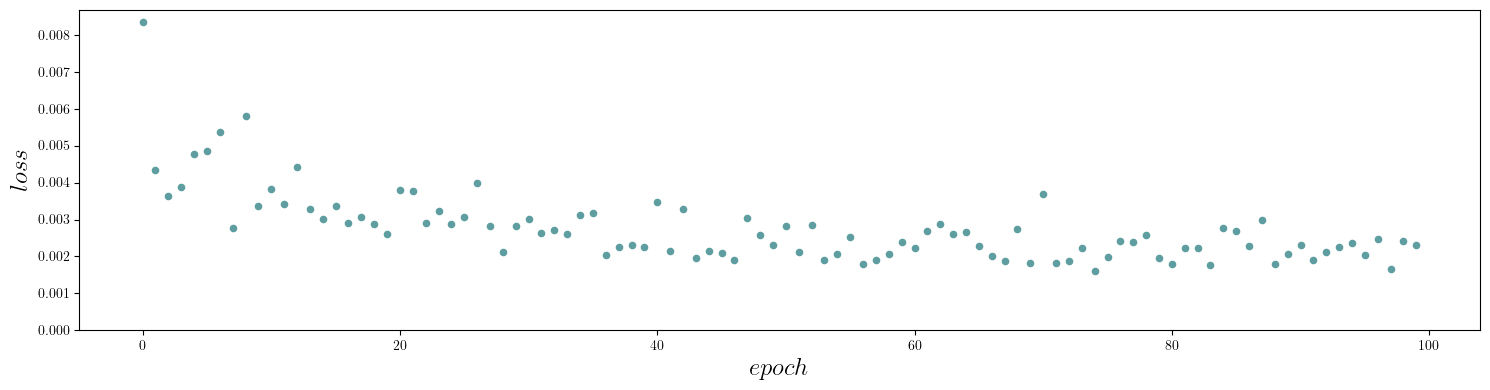

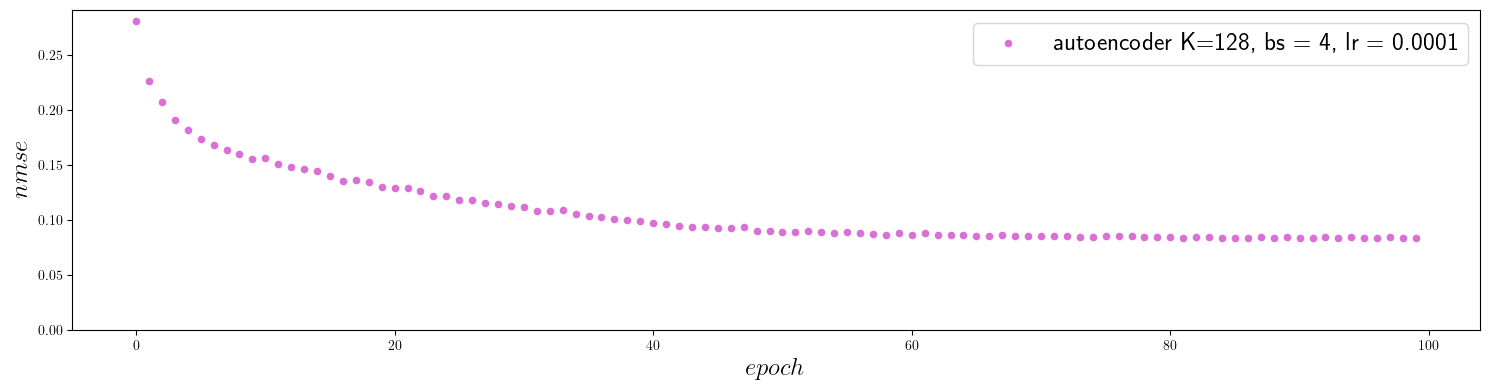

In [34]:
from utils import losses_from_info
epochs, losses, nmse, times = losses_from_info(variables)
i = 0


fig, ax1 = plt.subplots(figsize = (15, 4))
ax1.scatter(range(len(epochs[i:])), losses[i:], s = 20, c = 'cadetblue', label = r"autoencoder")
# ax1.scatter(range(len(epochs[i:])), losses_cnn[i:], s = 20, c = 'orange', label = r"cnn alone")
ax1.set_ylabel(r'$loss$', fontsize= fontsize)
ax1.set_xlabel(r'$epoch$', fontsize = fontsize)
ax1.set_ylim(bottom = 0)
# ax1.legend(fontsize = fontsize, loc = 'upper left')
fig.tight_layout()

fig, ax1 = plt.subplots(figsize = (15, 4))
ax1.scatter(range(len(epochs[i:])), nmse[i:], s = 20, c = 'orchid', label = rf"autoencoder K={K}, bs = {batch_size}, lr = {lr}")
# ax1.scatter(range(len(epochs[i:])), nmse_cnn[i:], s = 20, c = 'orange', label = fr"cnn alone, bs = {batch_size}, lr = {lr}")
ax1.set_ylabel(r'$nmse$', fontsize= fontsize)
ax1.set_xlabel(r'$epoch$', fontsize = fontsize)
ax1.legend(fontsize = fontsize, loc = 'upper right')
ax1.set_ylim(bottom = 0)


fig.tight_layout()

In [17]:
from autoencoder import ConvolutionalAutoencoder_debug
from training import SimuDataset, compute_nmse


test_set = SimuDataset(simulation, device,  rgb = True, mode = 'test', training_ratio = 0.9)
test_loader = DataLoader(dataset = test_set, batch_size = 4, shuffle = True)


def apply_autoencoder(test_loader, K, batch_size, nc = 64, encoded = False, directory = f'{current_directory}/results/autoencoder/cnn/'):
    autoencoder = ConvolutionalAutoencoder_debug(device, sizes, K = K, n_channels = nc, bias = False)

    autoencoder.load_state_dict(torch.load(directory + f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}.pt'))
    autoencoder.eval()  # Set the model to evaluation mode

    
    with torch.no_grad():
        encoded_data_batch = []
        decoded_data_batch = []

    for x, t in test_loader:
        x = x.to(device).float()
        encoded_data = autoencoder.encoder(x)
        encoded_data = autoencoder.linear_encoder(torch.reshape(encoded_data,  (encoded_data.shape[0],-1)))

        decoded_data = autoencoder.linear_decoder(encoded_data)
        decoded_data = autoencoder.decoder(torch.reshape(decoded_data, (decoded_data.shape[0], autoencoder.n_channels, autoencoder.sizes[-1][0], autoencoder.sizes[-1][1])))
        
        encoded_data_batch.append(encoded_data)
        decoded_data_batch.append(decoded_data)

    encoded_data_batch = torch.cat(encoded_data_batch, dim=0)
    decoded_data_batch = torch.cat(decoded_data_batch, dim=0)

    if encoded : 
        return decoded_data_batch, encoded_data_batch
    return decoded_data_batch

def compute_nmse_on_dataset(test_loader, K, batch_size, nc = 64, directory = f'{current_directory}/results/autoencoder/cnn/'):
    autoencoder = ConvolutionalAutoencoder_debug(device, sizes, K = K, n_channels = nc, bias = True)

    autoencoder.load_state_dict(torch.load(directory + f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}.pt'))
    autoencoder.eval()  # Set the model to evaluation mode

    
    with torch.no_grad():
        total_nmse = 0
        num_batches = 0

    for x, t in test_loader:
        
        x = x.to(device).float()
        x_noisy = x + torch.randn_like(x)*.1
        encoded_data = autoencoder.encoder(x_noisy)
        encoded_data = autoencoder.linear_encoder(torch.reshape(encoded_data,  (encoded_data.shape[0],-1)))

        decoded_data = autoencoder.linear_decoder(encoded_data)
        decoded_data = autoencoder.decoder(torch.reshape(decoded_data, (decoded_data.shape[0], autoencoder.n_channels, autoencoder.sizes[-1][0], autoencoder.sizes[-1][1])))
        
        nmse = compute_nmse(decoded_data, x)
        total_nmse += nmse
        num_batches += 1

    average_nmse = total_nmse / num_batches

    return average_nmse


# decoded_data, encoded_data = apply_autoencoder(test_loader, K, batch_size, encoded = True, directory=directory)

## Study of bs

In [13]:
bs_values = [4, 10 , 25, 50, 128]
t_test = int(0.9*m + 1)

nmse = []
nmse_test = []
nmse_train = []

for i, bs in enumerate(bs_values):
    decoded_data = apply_autoencoder(K, bs, encoded = False, directory = directory)

    nmse.append(compute_nmse(decoded_data.cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1))))
    nmse_train.append(compute_nmse(decoded_data[:t_test, :, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[:t_test, :, :, :])))
    nmse_test.append(compute_nmse(decoded_data[t_test:, :, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[t_test:, :, :, :])))

    # uz_decoded, uzmean_decoded = decoded_simulation.UZ()
    # plot_uz()
    # plt.savefig(f'../results/autoencoder/snapshots/uz_{i}.png',dpi=300)
    # plt.close()
    
print(nmse, nmse_test, nmse_train)

TypeError: apply_autoencoder() missing 1 required positional argument: 'batch_size'

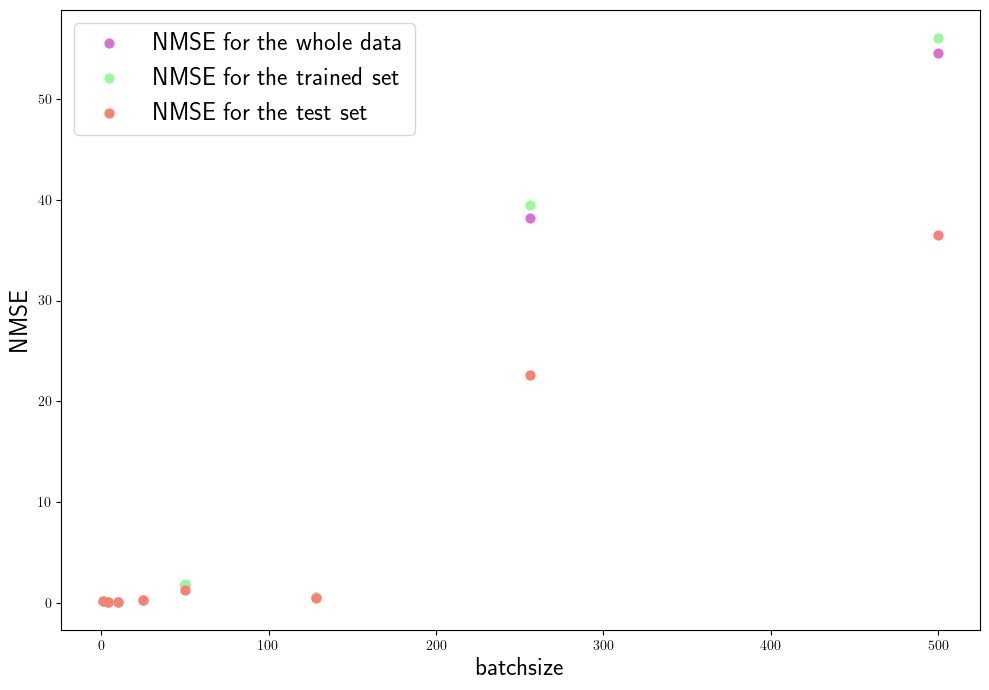

In [138]:
fig, ax2 = plt.subplots(figsize = (10, 7)) 
ax2.scatter(bs_values, nmse, s = 40, c = 'orchid', label = r"NMSE for the whole data")
ax2.scatter(bs_values, nmse_train, s = 40, c = 'palegreen', label = r"NMSE for the trained set")
ax2.scatter(bs_values, nmse_test, s = 40, c = 'salmon', label = r"NMSE for the test set")

# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'batchsize', fontsize = fontsize)
ax2.legend(fontsize = fontsize)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

## Study of K 

In [24]:
from utils import compute_nmse
from autoencoder import ConvolutionalAutoencoder_debug
from training import SimuDataset

# directory = f'{current_directory}/results/autoencoder/cnn/noisy'
# title = f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}_info.txt'

nc = 64
K_values = [2,3, 5, 10, 25, 50, 128, 256, 500, 700, 960, 1000, 2000]
# K_values = [1, 2,3, 5, 10, 25, 50, 128, 256, 500, 700, 960, 1000, 2000]
t_test = int(0.9*m + 1)
batch_size = 4


test_set = SimuDataset(simulation, device,  rgb = True, mode = 'test', training_ratio = 0.9)
test_loader = DataLoader(dataset = test_set, batch_size = 4, shuffle = True)

whole_set = SimuDataset(simulation, device,  rgb = True, mode = 'whole', training_ratio = 0.9)
whole_loader = DataLoader(dataset = whole_set, batch_size = 4, shuffle = True)

train_set = SimuDataset(simulation, device,  rgb = True, mode = 'train', training_ratio = 0.9)
train_loader = DataLoader(dataset = train_set, batch_size = 4, shuffle = True)


nmse = []
nmse_test = []
nmse_train = []

for i, K in enumerate(K_values):
    print(K)
    nmse.append(compute_nmse_on_dataset(whole_loader, K, batch_size, nc = nc, directory = directory))
    nmse_test.append(compute_nmse_on_dataset(test_loader, K, batch_size, nc = nc, directory = directory))
    nmse_train.append(compute_nmse_on_dataset(train_loader, K, batch_size, nc = nc, directory = directory))
    
print(nmse, nmse_test, nmse_train)

2
3
5
10
25
50
128
256
500
700
960
1000
2000
[2.3617570795583367, 1387.560894583179, 0.3685285661887045, 0.7682217530650399, 1.7539699718388475, 3.5261513240291387, 3.0564421362360465, 6.10559960762693, 1.2041424029854426, 4.2443911939544785, 3.366070285038148, 0.9596597903761674, 0.4732840002956194] [0.6886332848175304, 207.5783113252342, 0.3798221340916288, 0.9065974667433678, 1.3555355468823567, 1.2450629512918747, 2.2801942965235766, 6.3002102316804525, 1.6767762710787648, 2.8800307599695647, 2.894092493257889, 0.8051312830240474, 0.24558325653059745] [2.5331572741531376, 1517.2838011156311, 0.35356870299660026, 0.7440795006188827, 1.7221227051679606, 3.6931029006925358, 3.120083757337707, 6.039444557824309, 1.138454390509264, 4.445149059736091, 3.408502900016734, 0.9807044146782549, 0.5012159247452729]


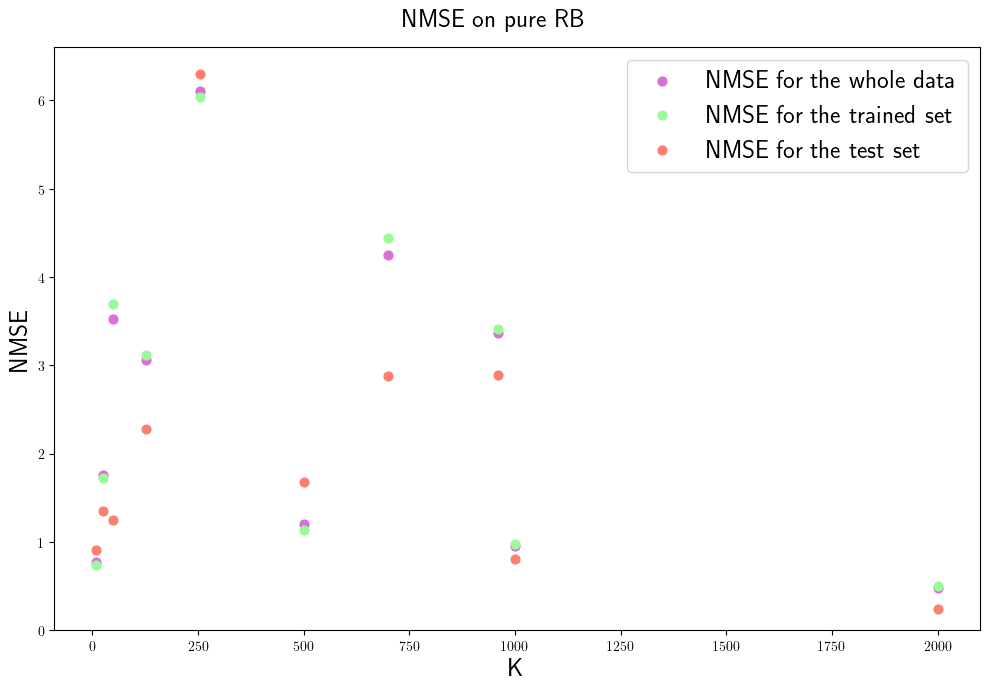

In [25]:
i = 3
j = len(K_values)

fig, ax2 = plt.subplots(figsize = (10, 7)) 
# ax2.scatter(K_values[i:j], nmse[i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data")
# ax2.scatter(K_values[i:j], nmse_train[i:j], s = 40, c = 'palegreen', label = r"NMSE for the trained set")
# ax2.scatter(K_values[i:j], nmse_test[i:j], s = 40, c = 'salmon', label = r"NMSE for the test set")

ax2.scatter(K_values[i:j], nmse[i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data")
ax2.scatter(K_values[i:j], nmse_train[i:j], s = 40, c = 'palegreen', label = r"NMSE for the trained set")
ax2.scatter(K_values[i:j], nmse_test[i:j], s = 40, c = 'salmon', label = r"NMSE for the test set")

# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'K', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
fig.suptitle(f'NMSE on pure RB', fontsize = fontsize)
fig.tight_layout()

# plt.savefig(f'{current_directory}fig/K_noisy', dpi=300)

## Study of nc

In [9]:
from utils import compute_nmse
from autoencoder import ConvolutionalAutoencoder_debug

directory = f'{current_directory}/results/autoencoder/cnn/time/'
# title = f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}_info.txt'

nc = 256
K_values = [1, 2,3, 5, 10, 25, 50, 128, 256, 500, 700, 960, 1000, 2000, 4000, 6000, 8000, 12393]
K_values = [1, 2,3, 5, 10, 25, 50, 128, 256, 500, 700, 960, 2000]
t_test = int(0.9*m + 1)
batch_size = 4
nc_values = [64, 128]
nmse_nc = {}
nmse_test_nc = {}

for nc in nc_values:
    nmse = []
    nmse_test = []

    for i, K in enumerate(K_values):
        print(K)
        decoded_data = apply_autoencoder(K, batch_size, nc = nc, encoded = False, directory = directory)

        nmse.append(compute_nmse(decoded_data.cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1))))
        nmse_test.append(compute_nmse(decoded_data[t_test:, :, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[t_test:, :, :, :])))

        # uz_decoded, uzmean_decoded = decoded_simulation.UZ()
        # plot_uz()
        # plt.savefig(f'../results/autoencoder/snapshots/uz_{i}.png',dpi=300)
        # plt.close()
    nmse_nc[f"{nc}"] = nmse
    nmse_test_nc[f"{nc}"] = nmse_test
    print(nmse, nmse_test)

1
2
3
5
10
25
50
128
256
500
700
960
2000
[0.3952187276484497, 0.2611261410296446, 0.2136397954521071, 0.17156271065894416, 0.14029968482369556, 0.19682411043442702, 0.10747153707524704, 0.10279035210879749, 0.09920155138427175, 0.1063881905848157, 0.10069190044761712, 0.10493820996185314, 0.1037075448143979] [0.410230156707384, 0.3371103994501727, 0.2953721491339996, 0.2579736728516005, 0.18574640819797839, 0.46663543672061764, 0.1328444242570729, 0.12563544354203093, 0.12334792673161221, 0.12803423129104302, 0.12372740977196946, 0.12949022782941372, 0.12658590941036396]
1
2
3
5
10
25
50
128
256
500
700
960
2000
[4.0263993167004895, 0.2748491302607739, 0.20266830371355207, 0.16128187957112644, 0.4278462440518652, 0.09854089925875367, 0.09067702508719469, 0.08867291191621028, 0.08918763852130583, 0.08475186964371627, 0.25938585870333297, 0.08800324249185608, 0.09092213105468899] [1.6042617115310023, 0.32529009339137793, 0.29523139958974526, 0.23481440195872955, 0.18612580460312958, 0.1

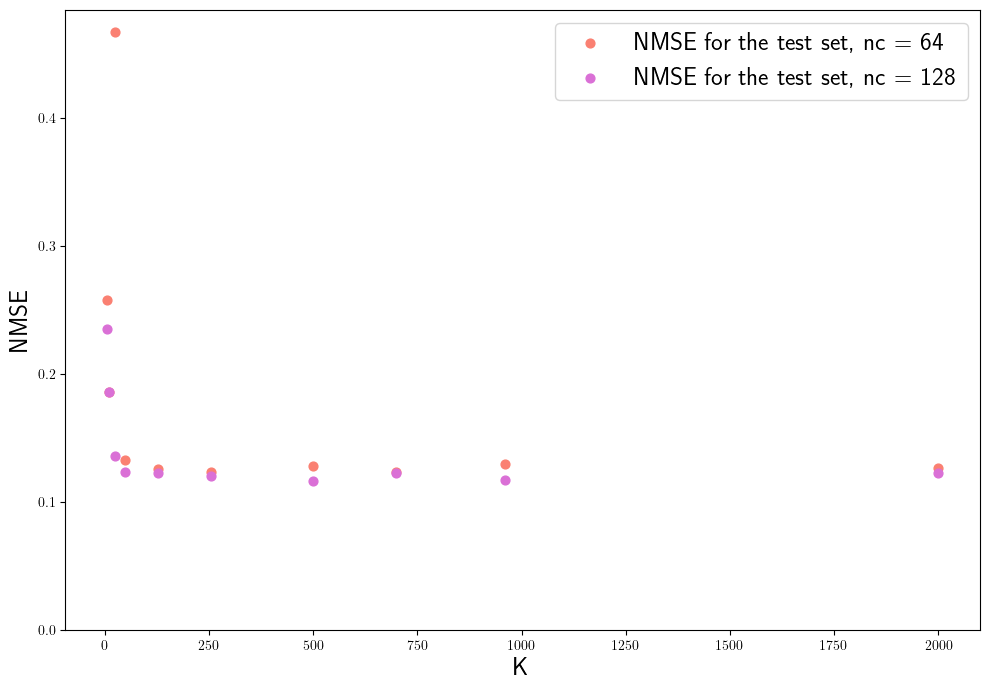

: 

In [12]:
i = 3
j = len(K_values)

fig, ax2 = plt.subplots(figsize = (10, 7)) 
# ax2.scatter(K_values[i:j], nmse_nc["64"][i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data, nc = 64")
ax2.scatter(K_values[i:j], nmse_test_nc["64"][i:j], s = 40, c = 'salmon', label = r"NMSE for the test set, nc = 64")
# ax2.scatter(K_values[i:j], nmse_nc["128"][i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data, nc = 128")
ax2.scatter(K_values[i:j], nmse_test_nc["128"][i:j], s = 40, c = 'orchid', label = r"NMSE for the test set, nc = 128")

# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'K', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

## NMSE for U, W and T

In [12]:
from utils import compute_nmse
from autoencoder import ConvolutionalAutoencoder_debug

directory = f'{current_directory}/results/autoencoder/cnn/time/'
# title = f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}_info.txt'

nc = 64
K_values = [1, 2,3, 5, 10, 25, 50, 128, 256, 500, 700, 960, 1000, 2000]
t_test = int(0.9*m + 1)
batch_size = 4



nmse_U = []
nmse_W = []
nmse_T = []

nmse_test_U = []
nmse_test_W = []
nmse_test_T = []

for i, K in enumerate(K_values):
    print(K)
    decoded_data = apply_autoencoder(K, batch_size, nc = nc, encoded = False, directory = directory)

    nmse_U.append(compute_nmse(decoded_data[:, 0, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[:, 0, :, :])))
    nmse_test_U.append(compute_nmse(decoded_data[t_test:, 0, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[t_test:, 0, :, :])))
    
    nmse_W.append(compute_nmse(decoded_data[:, 1, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[:, 1, :, :])))
    nmse_test_W.append(compute_nmse(decoded_data[t_test:, 1, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[t_test:, 1, :, :])))

    nmse_T.append(compute_nmse(decoded_data[:, 2, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[:, 2, :, :])))
    nmse_test_T.append(compute_nmse(decoded_data[t_test:, 2, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[t_test:, 2, :, :])))

    # uz_decoded, uzmean_decoded = decoded_simulation.UZ()
    # plot_uz()
    # plt.savefig(f'../results/autoencoder/snapshots/uz_{i}.png',dpi=300)
    # plt.close()
    


1
2
3
5
10
25
50
128
256
500
700
960
1000
2000


In [18]:
print(nmse_test_U)

[0.3790813989768221, 0.9817947181638723, 0.19454194241090997, 0.16123438052494496, 0.10428954636063086, 0.2631154909441562, 0.06635684521081762, 0.057633639195901754, 0.05980214201508309, 0.06146521504716282, 0.05861557840762462, 0.06453374232420912, 0.06312361855786036, 0.060779630169084116]


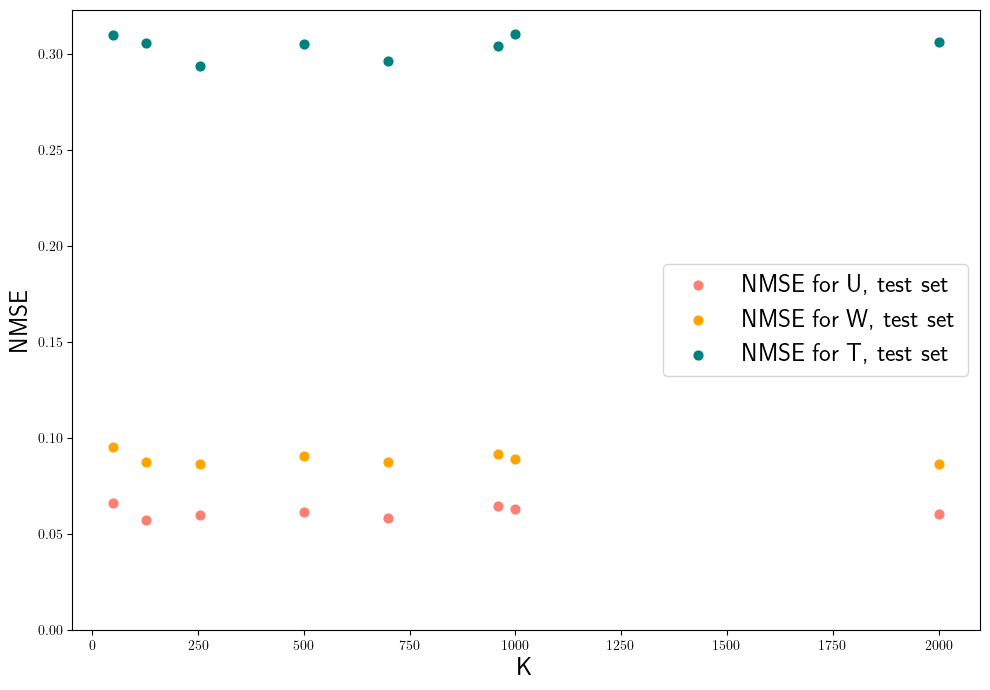

In [20]:
i = 6
j = len(K_values)

test = True

fig, ax2 = plt.subplots(figsize = (10, 7)) 
if not test:
    ax2.scatter(K_values[i:j], nmse_U[i:j], s = 40, c = 'salmon', label = r"NMSE for U, whole set")
    ax2.scatter(K_values[i:j], nmse_W[i:j], s = 40, c = 'orange', label = r"NMSE for W, whole set")
    ax2.scatter(K_values[i:j], nmse_T[i:j], s = 40, c = 'teal', label = r"NMSE for T, whole set")

if test:
    ax2.scatter(K_values[i:j], nmse_test_U[i:j], s = 40, c = 'salmon', label = r"NMSE for U, test set")
    ax2.scatter(K_values[i:j], nmse_test_W[i:j], s = 40, c = 'orange', label = r"NMSE for W, test set")
    ax2.scatter(K_values[i:j], nmse_test_T[i:j], s = 40, c = 'teal', label = r"NMSE for T, test set")
# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'K', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

## Timed algo

In [6]:
batch_size = 4
K = 128
lr = 1e-4
nc = 64
directory = f'{current_directory}/results/autoencoder/cnn/time/'
title = f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}_info.txt'

from utils import get_variables_from_info_text

variables, sizes = get_variables_from_info_text(directory, title)

K: 128
batch_size: 4
size1: (40, 25)
size2: (20, 12)
size3: (10, 6)
size4: (5, 3)
thirty_min_epoch: None
num_epoch: 100
lr: 0.0001
weight_decay: 0
execution_time_in_min: 19.888349107901256
epoch_1: {'loss': 0.02099001593887806, 'nmse': 0.5636502981185914, 'time': 0.39277878602345784}
epoch_2: {'loss': 0.012133033946156502, 'nmse': 0.4412666201591492, 'time': 0.7451534310976664}
epoch_3: {'loss': 0.008540981449186802, 'nmse': 0.35718493461608886, 'time': 1.099410359064738}
epoch_4: {'loss': 0.010021367110311985, 'nmse': 0.3352052569389343, 'time': 1.4498498916625977}
epoch_5: {'loss': 0.012683502398431301, 'nmse': 0.31684368252754214, 'time': 1.7886082808176675}
epoch_6: {'loss': 0.008142816834151745, 'nmse': 0.29536346197128294, 'time': 2.133576460679372}
epoch_7: {'loss': 0.004410472232848406, 'nmse': 0.27173487544059755, 'time': 2.480820886294047}
epoch_8: {'loss': 0.004663658794015646, 'nmse': 0.25177026093006133, 'time': 2.8261558095614117}
epoch_9: {'loss': 0.007156133186072111, '

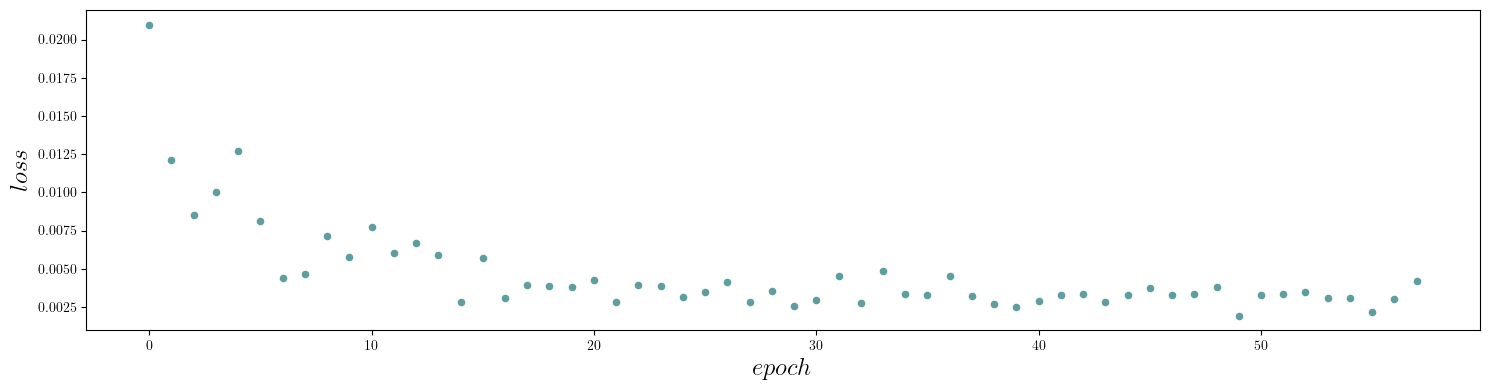

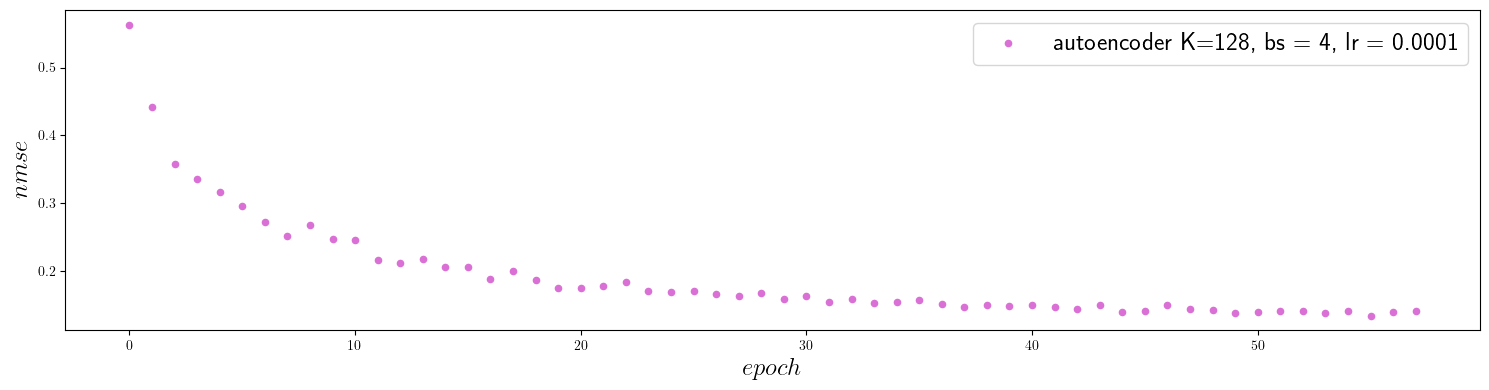

In [8]:
from utils import losses_from_info
epochs, losses, nmse, times = losses_from_info(variables)

i = 0

fig, ax1 = plt.subplots(figsize = (15, 4))
ax1.scatter(range(len(epochs[i:])), losses[i:], s = 20, c = 'cadetblue', label = r"autoencoder")
# ax1.scatter(range(len(epochs[i:])), losses_cnn[i:], s = 20, c = 'orange', label = r"cnn alone")
ax1.set_ylabel(r'$loss$', fontsize= fontsize)
ax1.set_xlabel(r'$epoch$', fontsize = fontsize)
# ax1.legend(fontsize = fontsize, loc = 'upper left')
fig.tight_layout()

fig, ax1 = plt.subplots(figsize = (15, 4))
ax1.scatter(range(len(epochs[i:])), nmse[i:], s = 20, c = 'orchid', label = rf"autoencoder K={K}, bs = {batch_size}, lr = {lr}")
# ax1.scatter(range(len(epochs[i:])), nmse_cnn[i:], s = 20, c = 'orange', label = fr"cnn alone, bs = {batch_size}, lr = {lr}")
ax1.set_ylabel(r'$nmse$', fontsize= fontsize)
ax1.set_xlabel(r'$epoch$', fontsize = fontsize)
ax1.legend(fontsize = fontsize, loc = 'upper right')

fig.tight_layout()

In [4]:
batch_size = 4
K = 10
lr = 1e-4
nc = 64

epoch_time=[]
final_nmse=[]
for K in K_values:
    directory = f'{current_directory}/results/autoencoder/cnn/time/'
    title = f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}_info.txt'

    variables, sizes = get_variables_from_info_text(directory, title)
    epochs, losses, nmse, times = losses_from_info(variables)
    epoch_time.append(epochs[-1])
    final_nmse.append(nmse[-1])

NameError: name 'K_values' is not defined

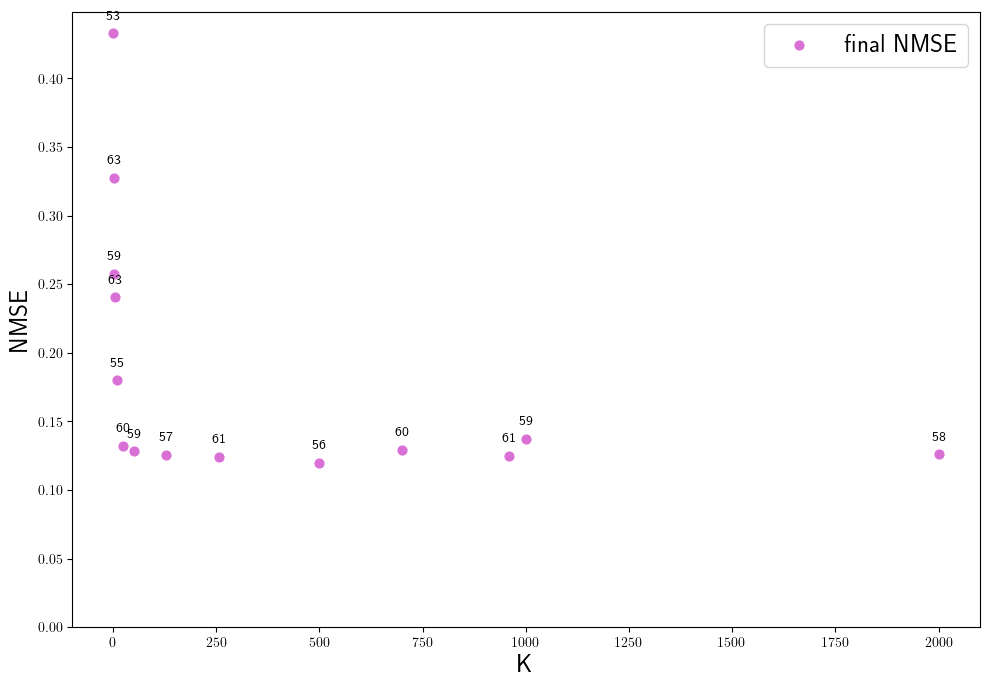

In [125]:
fig, ax2 = plt.subplots(figsize = (10, 7)) 
ax2.scatter(K_values, final_nmse, s = 40, c = 'orchid', label = r"final NMSE")

for i, txt in enumerate(final_nmse):
    ax2.annotate(f'{epoch_time[i]}', (K_values[i], final_nmse[i]), textcoords="offset points", xytext=(0,10), ha='center')


ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'K', fontsize = fontsize)
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

In [230]:
bs_values = [1, 4, 10 , 25, 50, 128, 256, 500]
t_test = int(0.9*m + 1)
K = 128
directory = f'{current_directory}/results/autoencoder/cnn/time/'
nmse = []
nmse_test = []
nmse_train = []

for i, bs in enumerate(bs_values):
    decoded_data = apply_autoencoder(K, bs, encoded = False, directory = directory)

    nmse.append(compute_nmse(decoded_data.cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1))))
    nmse_train.append(compute_nmse(decoded_data[:t_test, :, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[:t_test, :, :, :])))
    nmse_test.append(compute_nmse(decoded_data[t_test:, :, :, :].cpu(), torch.from_numpy(np.swapaxes(simulation.X_rgb, 0,1)[t_test:, :, :, :])))

    # uz_decoded, uzmean_decoded = decoded_simulation.UZ()
    # plot_uz()
    # plt.savefig(f'../results/autoencoder/snapshots/uz_{i}.png',dpi=300)
    # plt.close()
    
print(nmse, nmse_test, nmse_train)

[0.19669380963066127, 0.1027903521511962, 0.10218504641874193, 17.455922539074937, 4.152607651739788, 2.9849752398631657, 0.6415960733422739, 37.62419596486407] [0.22207587631672787, 0.125635443540499, 0.119180989446167, 10.325304215196795, 1.6238866340407845, 1.8465681445560014, 0.7505515387599201, 16.511059185175696] [0.19457514335882023, 0.1008834497227107, 0.10076637820327689, 18.051122320362467, 4.363682502237892, 3.07999920880482, 0.6325014526177989, 39.38653042490421]


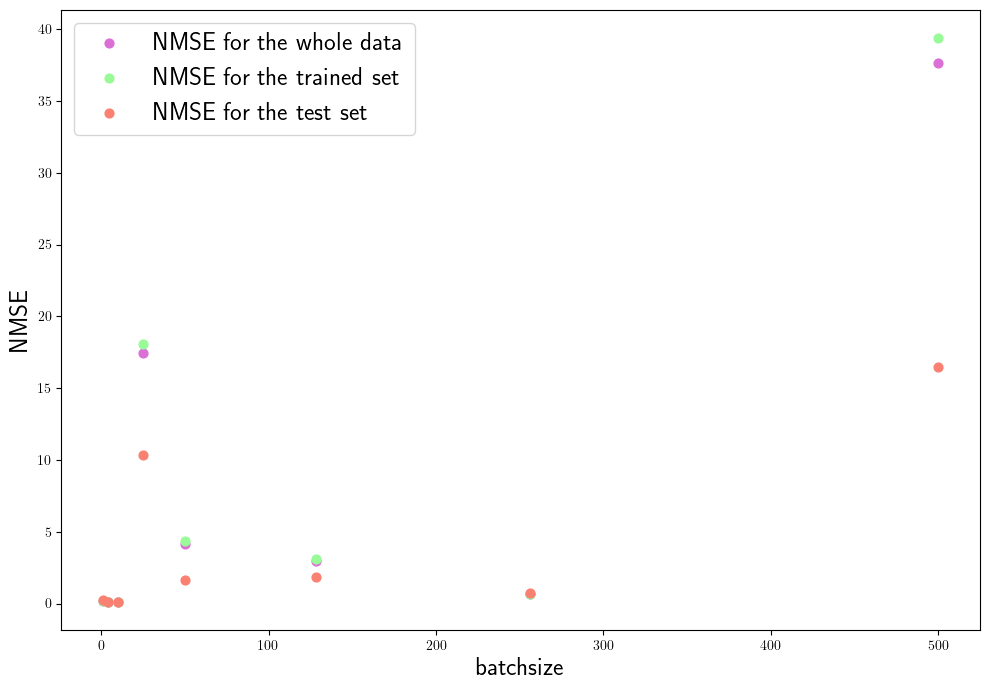

In [234]:
fig, ax2 = plt.subplots(figsize = (10, 7)) 
ax2.scatter(bs_values, nmse, s = 40, c = 'orchid', label = r"NMSE for the whole data")
ax2.scatter(bs_values, nmse_train, s = 40, c = 'palegreen', label = r"NMSE for the trained set")
ax2.scatter(bs_values, nmse_test, s = 40, c = 'salmon', label = r"NMSE for the test set")



# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'batchsize', fontsize = fontsize)
ax2.legend(fontsize = fontsize)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

## Gif

In [147]:
simulation.X_rgb.shape

(3, 6249, 81, 51)

In [191]:
from matplotlib import cm
def plot_fields(Simu_list, title, t, normalization = None, save=False, directory=None):
        fig, ax = plt.subplots(figsize=(15, 5), nrows = len(Simu_list), ncols =1)
        for i, simu in enumerate(Simu_list):
            u = simu.u
            w = simu.w
            T = simu.T

            vmin = simu.T[:, :, :].min()
            vmax = simu.T[:, :, :].max()
            abs_max = max(abs(vmin), abs(vmax))

            ax[i].streamplot(
                simu.x.T,
                simu.z.T,
                u[t, :, :].T,
                w[t, :, :].T,
                color="k",
                arrowsize=0.7,
                linewidth=1,
            )
            levels = np.linspace(vmin, vmax, 20)
            cf0 = ax[i].contourf(
                simu.x,
                simu.z,
                T[t, :, :],
                levels=levels,
                cmap=cm.Spectral.reversed(),
                norm=matplotlib.colors.Normalize(vmin=vmin, vmax=vmax),
            )
            cbar = plt.colorbar(cf0, ax=ax[i], shrink=0.9, aspect=6, ticks= [vmin, 0, vmax])
            # cbar.ax[i].set_aspect("auto")
            ax[i].set_title(title[i])
            ax[i].set_aspect("equal")
            ax[i].set_ylim(0, 1)
            ax[i].set_xlim(-4, 4)
        fig.suptitle(rf"field at t = {t}", fontsize = fontsize)

        if save:
            plt.savefig(directory, dpi=300)
            plt.close()
        else:
            plt.tight_layout()
            plt.show()

In [196]:
bs

4

In [223]:
t = 1645
for t in range(1630, 1700):
    plot_fields([simulation, decoded_simulation, residual_simulation], [r"GT", r"decoded", r"residual"],t, directory = f"../results/autoencoder/cnn/snapshots/field_{t}", save = True)

In [224]:
from utils import make_gif

make_gif(f'{current_directory}/results/autoencoder/cnn/snapshots/', f'{current_directory}/results/gif/cae/comparaison_bs{batch_size}_test_K{K}.gif', 10)

GIF created at: ..//results/gif/cae/comparaison_bs4_test_K2000.gif


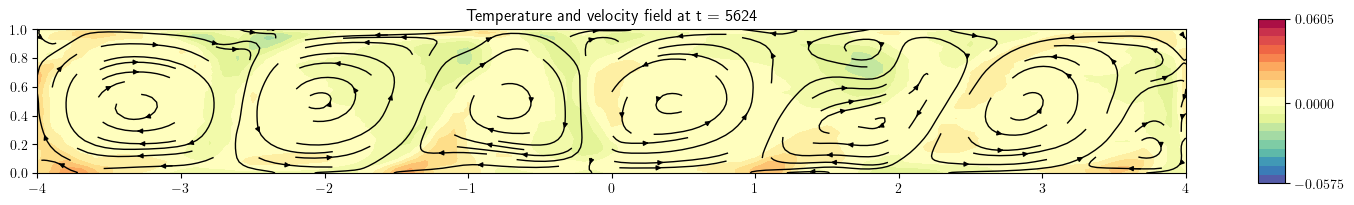

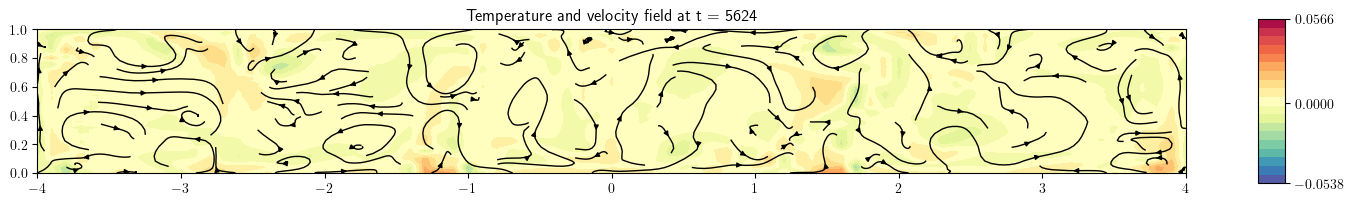

Ground Truth :


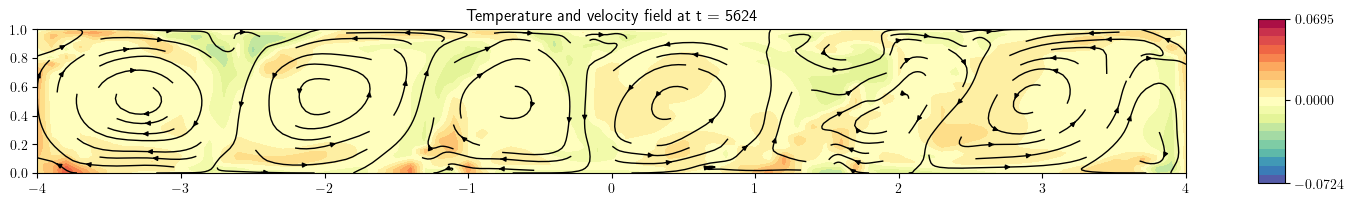

In [222]:
from data_analysis import Simulation
t = 5624

Umax = simulation.Umax
Wmax = simulation.Wmax
Tmax = simulation.Tmax


decoded_simulation = Simulation(current_directory, normalize = False)
decoded_simulation.reconstruct_simulation(decoded_data.cpu().numpy(), rgb = True, normalize = [Umax, Wmax, Tmax])
decoded_simulation.plot_field(t)

residual_simulation = Simulation(current_directory, normalize = False)
residual_simulation.reconstruct_simulation(decoded_data.cpu().numpy() - np.swapaxes(simulation.X_rgb, 0, 1), rgb = True, normalize = [Umax, Wmax, Tmax])
residual_simulation.plot_field(t)
print('Ground Truth :')
simulation.plot_field(t)

In [30]:
decoded_simulation.save_clip(1550, 1650, f'{current_directory}/results/autoencoder/cnn/snapshots/')

from utils import make_gif

make_gif(f'{current_directory}/results/autoencoder/cnn/snapshots/', f'{current_directory}/results/gif/cnn_decoded_field_bs{batch_size}_test_K={K}.gif', 10)

GIF created at: ..//results/gif/cnn_decoded_field_bs4_test_K=128.gif


In [39]:
uz_decoded, uzmean_decoded = decoded_simulation.UZ()
uz, uzmean = simulation.UZ()

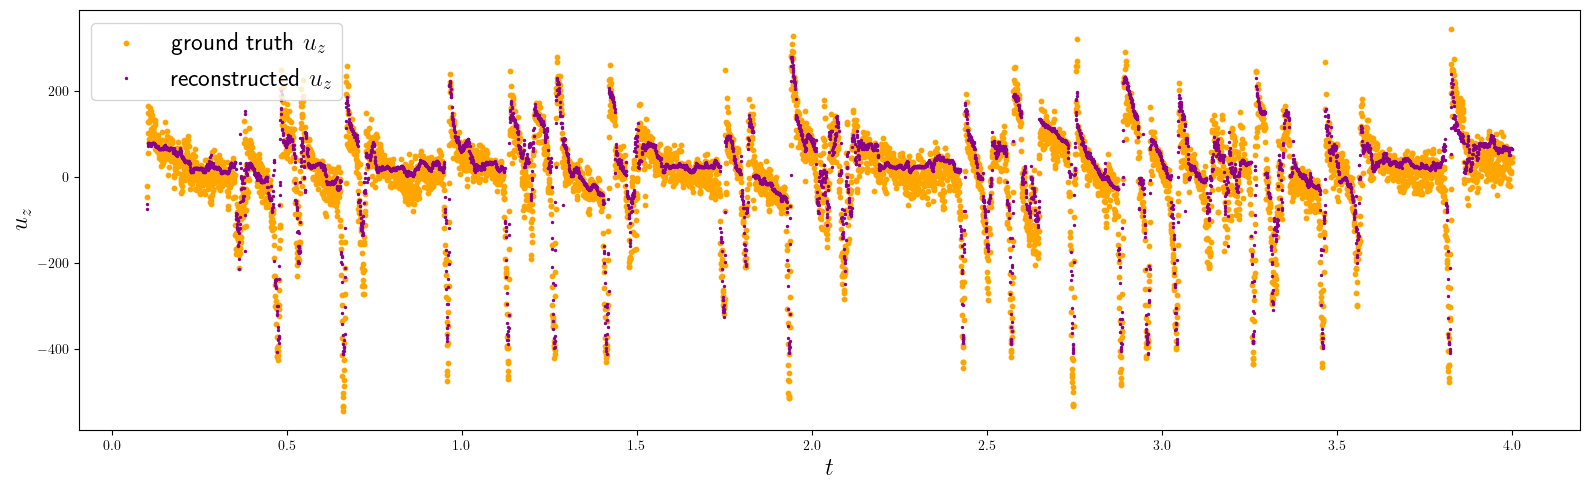

In [40]:
fig, ax1 = plt.subplots(figsize = (16, 5))


ax1.scatter(time.cpu(), uz, s = 10, c = 'orange', label = r'ground truth $u_z$')
ax1.scatter(time.cpu(), uz_decoded + uzmean, s = 2, c = 'darkmagenta', label = r'reconstructed $u_z$')

ax1.set_ylabel(r'$u_z$', fontsize= fontsize)
ax1.set_xlabel(r'$t$', fontsize = fontsize)
ax1.legend(fontsize = fontsize, loc = 'upper left')

fig.tight_layout()